# DSCI 525 Milestone 1

In [1]:
import re
import glob
import zipfile
from pathlib import Path
import json
import requests
import pandas as pd
from urllib.request import urlretrieve

In [2]:
import time, psutil, os, functools

_proc = psutil.Process(os.getpid())

def measure(fn):
    @functools.wraps(fn)
    def wrapper(*args, **kwargs):
        m0 = _proc.memory_info().rss / 1e6
        c0 = time.process_time()
        t0 = time.perf_counter()
        out = fn(*args, **kwargs)
        print(f"{fn.__name__}:  wall={time.perf_counter()-t0:.1f}s  "
              f"cpu={time.process_time()-c0:.1f}s  "
              f"mem Δ{_proc.memory_info().rss/1e6 - m0:+.0f} MB")
        return out
    return wrapper

## 1. Downloading the Data

In [3]:
WORKDIR = Path.cwd()
OUTPUT_DIR = WORKDIR / "figsharerainfall"
OUTPUT_DIR.mkdir(exist_ok=True)
FORCE_DOWNLOAD = False 

In [4]:
# Necessary metadata
article_id = 14096681
url = f"https://api.figshare.com/v2/articles/{article_id}"
headers = {"Content-Type": "application/json"}
output_directory = "figsharerainfall/"

In [ ]:
# List of data in the figshare repo
response = requests.request("GET", url, headers=headers)
data = json.loads(response.text)
files = data["files"]
files

[{'id': 26579150,
  'name': 'daily_rainfall_2014.png',
  'size': 58863,
  'is_link_only': False,
  'download_url': 'https://ndownloader.figshare.com/files/26579150',
  'supplied_md5': 'fd32a2ffde300a31f8d63b1825d47e5e',
  'computed_md5': 'fd32a2ffde300a31f8d63b1825d47e5e',
  'mimetype': 'image/png'},
 {'id': 26579171,
  'name': 'environment.yml',
  'size': 192,
  'is_link_only': False,
  'download_url': 'https://ndownloader.figshare.com/files/26579171',
  'supplied_md5': '060b2020017eed93a1ee7dd8c65b2f34',
  'computed_md5': '060b2020017eed93a1ee7dd8c65b2f34',
  'mimetype': 'text/plain'},
 {'id': 26586554,
  'name': 'README.md',
  'size': 5422,
  'is_link_only': False,
  'download_url': 'https://ndownloader.figshare.com/files/26586554',
  'supplied_md5': '61858c6cc0e6a6d6663a7e4c75bbd88c',
  'computed_md5': '61858c6cc0e6a6d6663a7e4c75bbd88c',
  'mimetype': 'text/x-python'},
 {'id': 26766812,
  'name': 'data.zip',
  'size': 814041183,
  'is_link_only': False,
  'download_url': 'https://n

In [ ]:
# Download data.zip from figshare
files_to_dl = ["data.zip"]
for file in files:
    if file["name"] in files_to_dl:

        output_path = OUTPUT_DIR / file["name"]

        if output_path.exists() and not FORCE_DOWNLOAD:
            print(f"{file['name']} already exists. Skipping download.")
        else:
            output_path.parent.mkdir(exist_ok=True)

            print(f"Downloading {file['name']}...")
            urlretrieve(file["download_url"], output_path)

data.zip already exists. Skipping download.


In [ ]:
# Extract files into data/ folder
zip_path = OUTPUT_DIR / "data.zip"
extract_dir = OUTPUT_DIR / "data"

if not extract_dir.exists():
    print("Extracting files...")
    with zipfile.ZipFile(zip_path, "r") as f:
        f.extractall(extract_dir)
else:
    print("Files already extracted. Skipping extraction.")

Extracting files...


In [8]:
%ls -ltr figsharerainfall/data/

total 10443656
-rw-r--r--@  1 oswingan  staff   95376895 Mar 26 21:08 MPI-ESM-1-2-HAM_daily_rainfall_NSW.csv
-rw-r--r--@  1 oswingan  staff   94960113 Mar 26 21:08 AWI-ESM-1-1-LR_daily_rainfall_NSW.csv
-rw-r--r--@  1 oswingan  staff   82474546 Mar 26 21:08 NorESM2-LM_daily_rainfall_NSW.csv
-rw-r--r--@  1 oswingan  staff  127613760 Mar 26 21:08 ACCESS-CM2_daily_rainfall_NSW.csv
-rw-r--r--@  1 oswingan  staff  232118894 Mar 26 21:08 FGOALS-f3-L_daily_rainfall_NSW.csv
-rw-r--r--@  1 oswingan  staff  330360682 Mar 26 21:08 CMCC-CM2-HR4_daily_rainfall_NSW.csv
-rw-r--r--@  1 oswingan  staff  254009247 Mar 26 21:08 MRI-ESM2-0_daily_rainfall_NSW.csv
-rw-r--r--@  1 oswingan  staff  235661418 Mar 26 21:08 GFDL-CM4_daily_rainfall_NSW.csv
-rw-r--r--@  1 oswingan  staff  294260911 Mar 26 21:08 BCC-CSM2-MR_daily_rainfall_NSW.csv
-rw-r--r--@  1 oswingan  staff  295768615 Mar 26 21:08 EC-Earth3-Veg-LR_daily_rainfall_NSW.csv
-rw-r--r--@  1 oswingan  staff  328852379 Mar 26 21:08 CMCC-ESM2_daily_rainfal

## 2. Combining data CSVs

In [ ]:
@measure
def combine_csvs(data_dir, output_path):
    # If combined file exists, skip and return file
    output_path = Path(output_path)
    if output_path.exists():
        print(f"{output_path.name} already exists. Skipping.")
        return pd.read_csv(output_path)
    
    data_dir = Path(data_dir)
    csv_files = [
        file for file in glob.glob(str(data_dir / "*.csv"))
        if Path(file).name != "observed_daily_rainfall_SYD.csv"
    ]
    
    dfs = []
    for filepath in csv_files:
        filename = Path(filepath).name
        model = re.search(r"([^_]*)", filename).group(1)
        df = pd.read_csv(filepath)
        df["model"] = model
        dfs.append(df)
    
    combined = pd.concat(dfs, ignore_index=True)
    combined.to_csv(output_path, index=False)
    return combined

In [10]:
combined_df = combine_csvs(OUTPUT_DIR / "data", OUTPUT_DIR / "combined_rainfall.csv")
combined_df.to_csv(OUTPUT_DIR / "combined_rainfall.csv", index=False)
combined_df

combine_csvs:  wall=239.7s  cpu=228.1s  mem Δ+3396 MB


,time,lat_min,lat_max,lon_min,lon_max,rain (mm/day),model
0,1889-01-01 12:00:00,-35.439867,-33.574619,141.5625,143.4375,4.244226e-13,MPI-ESM-1-2-HAM
1,1889-01-02 12:00:00,-35.439867,-33.574619,141.5625,143.4375,4.217326e-13,MPI-ESM-1-2-HAM
2,1889-01-03 12:00:00,-35.439867,-33.574619,141.5625,143.4375,4.498125e-13,MPI-ESM-1-2-HAM
3,1889-01-04 12:00:00,-35.439867,-33.574619,141.5625,143.4375,4.251282e-13,MPI-ESM-1-2-HAM
4,1889-01-05 12:00:00,-35.439867,-33.574619,141.5625,143.4375,4.270161e-13,MPI-ESM-1-2-HAM
...,...,...,...,...,...,...,...
62467838,2014-12-27 12:00:00,-30.157068,-29.214660,153.1250,154.3750,6.689683e+00,SAM0-UNICON
62467839,2014-12-28 12:00:00,-30.157068,-29.214660,153.1250,154.3750,7.862555e+00,SAM0-UNICON
62467840,2014-12-29 12:00:00,-30.157068,-29.214660,153.1250,154.3750,1.000503e+01,SAM0-UNICON
62467841,2014-12-30 12:00:00,-30.157068,-29.214660,153.1250,154.3750,8.541592e+00,SAM0-UNICON


In [11]:
# Remove uncombined data to free up hard drive space
import shutil
shutil.rmtree(OUTPUT_DIR / "data")

### Comparison

The speed of combining differs significantly across machines. Notable is the difference between Windows and MacOS, with the latter being noticably faster to execute. In every case, wall ~ cpu time, meaning the function was bottlenecked by computing and not I/O. Surprisingly, memory delta also was different between group members, possibly due to individual implementations of the combine function or difference between how operating systems handle memory.

## 3. EDA in Python

In [ ]:
# 1. Change dtype
@measure
def eda_change_dtype(filepath):
    df = pd.read_csv(filepath)
    df["model"] = df["model"].astype("category")
    print(df["model"].value_counts())
    return df

# 2. Load only necessary columns
@measure
def eda_select_columns(filepath):
    use_cols = ["model"]
    df = pd.read_csv(filepath, usecols=use_cols)
    print(df["model"].value_counts())
    return df

# 3. Load in chunks
@measure
def eda_chunked(filepath, chunksize=1_000_000):
    counts = pd.Series(dtype="int64")
    for chunk in pd.read_csv(filepath, chunksize=chunksize):
        counts = counts.add(chunk["model"].value_counts(), fill_value=0)
    print(counts.astype(int))

In [13]:
eda_change_dtype(OUTPUT_DIR / "combined_rainfall.csv")

model
MPI-ESM1-2-HR       5154240
TaiESM1             3541230
NorESM2-MM          3541230
CMCC-CM2-HR4        3541230
CMCC-CM2-SR5        3541230
CMCC-ESM2           3541230
SAM0-UNICON         3541153
FGOALS-f3-L         3219300
GFDL-CM4            3219300
GFDL-ESM4           3219300
EC-Earth3-Veg-LR    3037320
MRI-ESM2-0          3037320
BCC-CSM2-MR         3035340
MIROC6              2070900
ACCESS-CM2          1932840
ACCESS-ESM1-5       1610700
INM-CM5-0           1609650
INM-CM4-8           1609650
KIOST-ESM           1287720
FGOALS-g3           1287720
MPI-ESM1-2-LR        966420
NESM3                966420
AWI-ESM-1-1-LR       966420
MPI-ESM-1-2-HAM      966420
NorESM2-LM           919800
BCC-ESM1             551880
CanESM5              551880
Name: count, dtype: int64
eda_change_dtype:  wall=40.6s  cpu=38.7s  mem Δ-1370 MB


,time,lat_min,lat_max,lon_min,lon_max,rain (mm/day),model
0,1889-01-01 12:00:00,-35.439867,-33.574619,141.5625,143.4375,4.244226e-13,MPI-ESM-1-2-HAM
1,1889-01-02 12:00:00,-35.439867,-33.574619,141.5625,143.4375,4.217326e-13,MPI-ESM-1-2-HAM
2,1889-01-03 12:00:00,-35.439867,-33.574619,141.5625,143.4375,4.498125e-13,MPI-ESM-1-2-HAM
3,1889-01-04 12:00:00,-35.439867,-33.574619,141.5625,143.4375,4.251282e-13,MPI-ESM-1-2-HAM
4,1889-01-05 12:00:00,-35.439867,-33.574619,141.5625,143.4375,4.270161e-13,MPI-ESM-1-2-HAM
...,...,...,...,...,...,...,...
62467838,2014-12-27 12:00:00,-30.157068,-29.214660,153.1250,154.3750,6.689683e+00,SAM0-UNICON
62467839,2014-12-28 12:00:00,-30.157068,-29.214660,153.1250,154.3750,7.862555e+00,SAM0-UNICON
62467840,2014-12-29 12:00:00,-30.157068,-29.214660,153.1250,154.3750,1.000503e+01,SAM0-UNICON
62467841,2014-12-30 12:00:00,-30.157068,-29.214660,153.1250,154.3750,8.541592e+00,SAM0-UNICON


In [14]:
eda_select_columns(OUTPUT_DIR / "combined_rainfall.csv")

model
MPI-ESM1-2-HR       5154240
CMCC-CM2-HR4        3541230
CMCC-ESM2           3541230
CMCC-CM2-SR5        3541230
NorESM2-MM          3541230
TaiESM1             3541230
SAM0-UNICON         3541153
GFDL-ESM4           3219300
FGOALS-f3-L         3219300
GFDL-CM4            3219300
MRI-ESM2-0          3037320
EC-Earth3-Veg-LR    3037320
BCC-CSM2-MR         3035340
MIROC6              2070900
ACCESS-CM2          1932840
ACCESS-ESM1-5       1610700
INM-CM4-8           1609650
INM-CM5-0           1609650
FGOALS-g3           1287720
KIOST-ESM           1287720
AWI-ESM-1-1-LR       966420
MPI-ESM1-2-LR        966420
NESM3                966420
MPI-ESM-1-2-HAM      966420
NorESM2-LM           919800
BCC-ESM1             551880
CanESM5              551880
Name: count, dtype: int64
eda_select_columns:  wall=19.5s  cpu=19.2s  mem Δ-1092 MB


,model
0,MPI-ESM-1-2-HAM
1,MPI-ESM-1-2-HAM
2,MPI-ESM-1-2-HAM
3,MPI-ESM-1-2-HAM
4,MPI-ESM-1-2-HAM
...,...
62467838,SAM0-UNICON
62467839,SAM0-UNICON
62467840,SAM0-UNICON
62467841,SAM0-UNICON


In [15]:
eda_chunked(OUTPUT_DIR / "combined_rainfall.csv")

model
ACCESS-CM2          1932840
ACCESS-ESM1-5       1610700
AWI-ESM-1-1-LR       966420
BCC-CSM2-MR         3035340
BCC-ESM1             551880
CMCC-CM2-HR4        3541230
CMCC-CM2-SR5        3541230
CMCC-ESM2           3541230
CanESM5              551880
EC-Earth3-Veg-LR    3037320
FGOALS-f3-L         3219300
FGOALS-g3           1287720
GFDL-CM4            3219300
GFDL-ESM4           3219300
INM-CM4-8           1609650
INM-CM5-0           1609650
KIOST-ESM           1287720
MIROC6              2070900
MPI-ESM-1-2-HAM      966420
MPI-ESM1-2-HR       5154240
MPI-ESM1-2-LR        966420
MRI-ESM2-0          3037320
NESM3                966420
NorESM2-LM           919800
NorESM2-MM          3541230
SAM0-UNICON         3541153
TaiESM1             3541230
dtype: int64
eda_chunked:  wall=37.8s  cpu=37.4s  mem Δ-965 MB


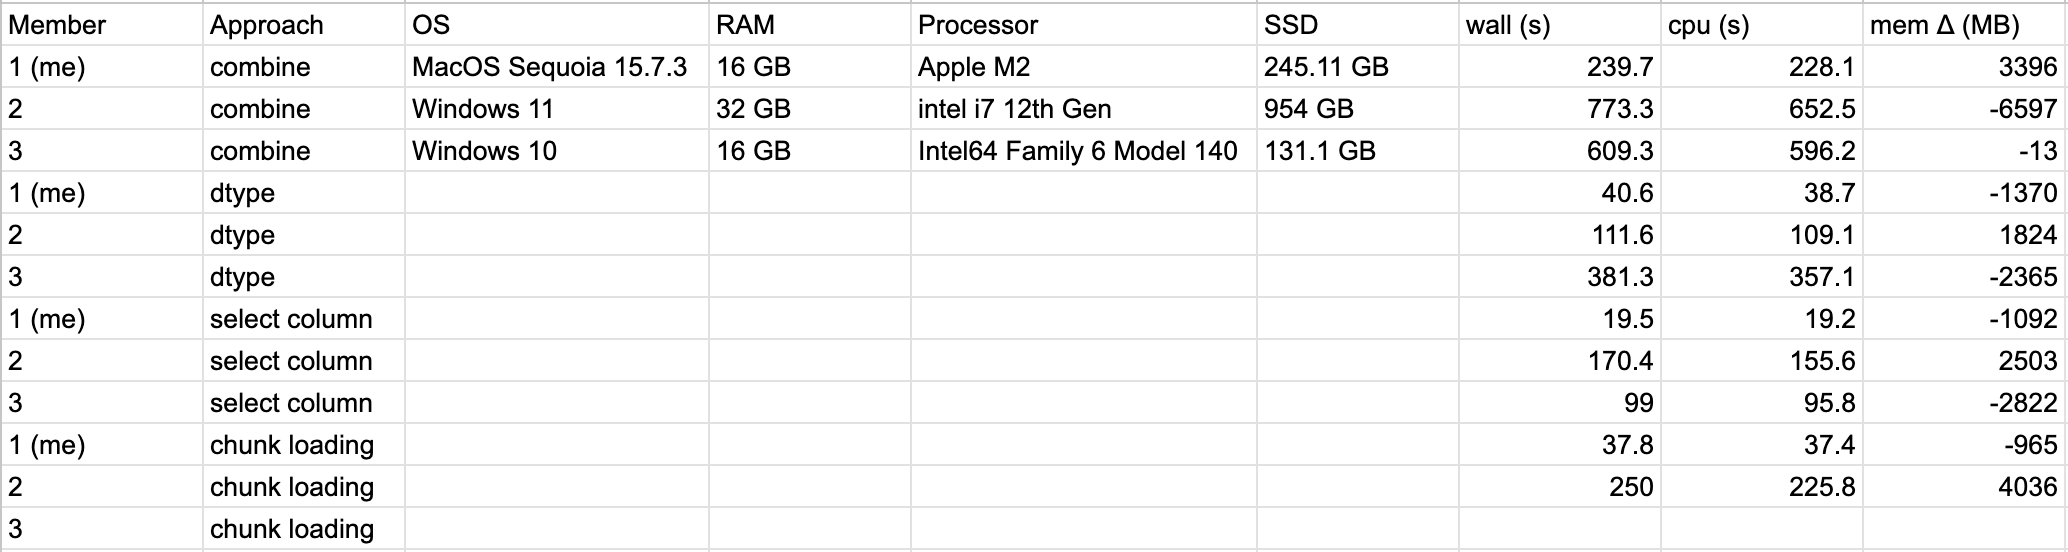

### Comparison

On my machine, changing dtype was the most efficient in reducing memory, but also had the longest run time. Selecting the appropriate columns was the fastest with a slightly lower reduction in memory. Chunk loading had long wall time and the least memory reduction. I would choose column selection in practice, as only reading the appropriate columns leads to a large decrease in execution time. This was also the case for group member 2, but not member 3, for whom all approches somehow resulted in a positive memory delta.

## 4. EDA in R

I was not able to get rpy2 to run locally, so I opted to create an R markdown notebook and perform my analysis there. The code and corresponding outputs are documented below. I opted to use parquet file via arrow, as it preserves dtypes and is more efficient in read/write than csv file.

In [16]:
combined_df.to_parquet(OUTPUT_DIR / "combined_rainfall.parquet", index=False)

```
install.packages("arrow")
library(arrow)

df <- read_parquet("figsharerainfall/combined_rainfall.parquet")
head(df)
```

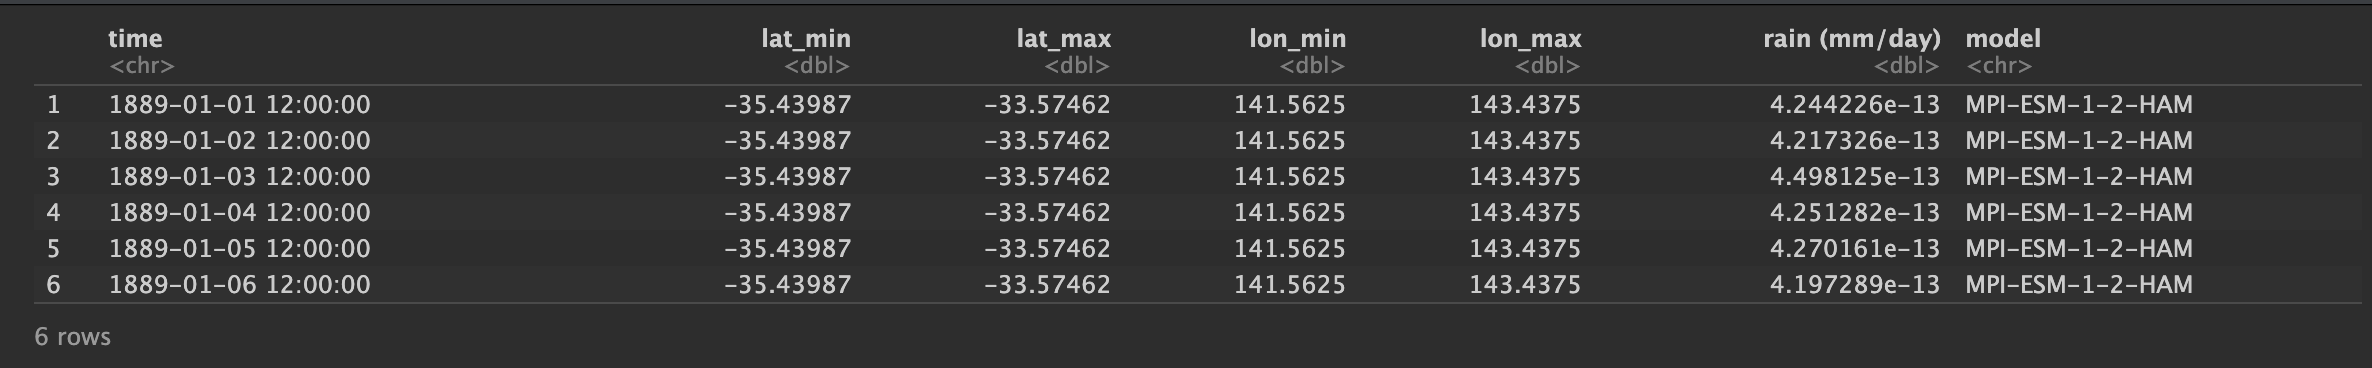

```
table(df$model)
```

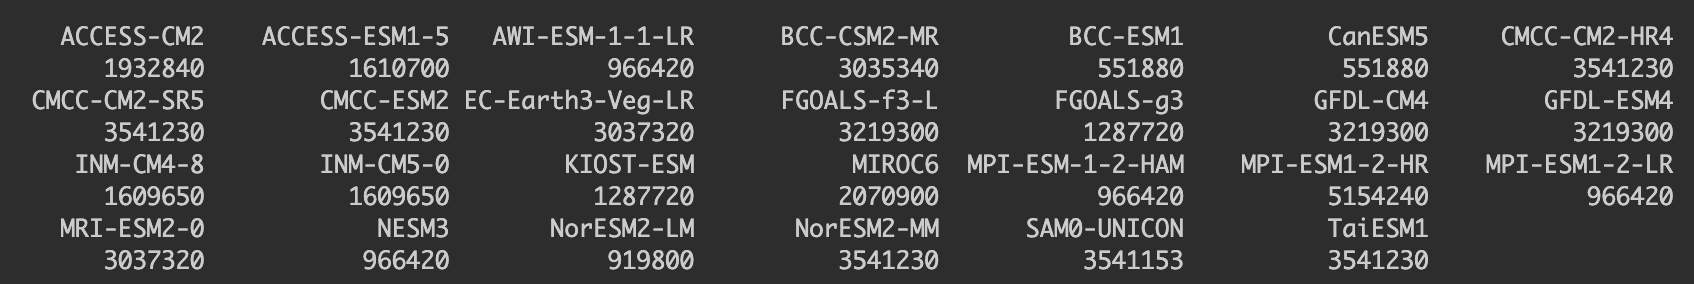